In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.dates as mdates
import torch
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.calibration import calibration_curve

from gru_signals import (
    VRPMRNet, VRPMRDataset,
    build_vrp_targets, build_mr_targets,
    vrp_loss, mr_loss,
)
from utils import log_returns, rogers_satchell_rv, realized_semivariance, volume_ratio

torch.manual_seed(42)
np.random.seed(42)

regime_colors = [
    ('Pre dot-com',  '#2196F3', '1993-01-01', '2000-03-10'),
    ('Dot-com bust', '#F44336', '2000-03-10', '2002-10-09'),
    ('Mid-cycle',    '#4CAF50', '2002-10-09', '2007-10-09'),
    ('GFC',          '#9C27B0', '2007-10-09', '2009-03-09'),
    ('Recovery',     '#FF9800', '2009-03-09', '2020-02-19'),
    ('COVID',        '#E91E63', '2020-02-19', '2021-06- 01'),
    ('Post-COVID',   '#009688', '2021-06-01', '2030-01-01'),
]
legend_patches = [mpatches.Patch(color=c, label=l) for l, c, _, _ in regime_colors]

## Load DMM artifacts

In [3]:
d = np.load('dmm_artifacts.npz', allow_pickle=True)

f_tr     = d['f_tr']       # (T_tr, 6) fast state posterior means
f_te     = d['f_te']       # (T_te, 6)
f_std_tr = d['f_std_tr']   # (T_tr, 6) fast state posterior stds
f_std_te = d['f_std_te']   # (T_te, 6)

# Emission params needed for residuals
fast_ep_tr = {
    'st_mu':  d['fast_ep_tr_st_mu'],   # (T_tr, 4): ret, rv, log_vix, gap
    'ln_mu':  d['fast_ep_tr_ln_mu'],   # (T_tr, 1): rsv_down
}
fast_ep_te = {
    'st_mu':  d['fast_ep_te_st_mu'],
    'ln_mu':  d['fast_ep_te_ln_mu'],
}

log_ret_tr = d['log_ret_tr']   # (T_tr,) raw log returns
log_ret_te = d['log_ret_te']   # (T_te,)

fast_train_dates = pd.to_datetime(d['fast_train_dates'])
fast_test_dates  = pd.to_datetime(d['fast_test_dates'])

T_tr = len(f_tr)
T_te = len(f_te)
print(f'Train: {T_tr} days  ({fast_train_dates[0].date()} → {fast_train_dates[-1].date()})')
print(f'Test : {T_te} days  ({fast_test_dates[0].date()} → {fast_test_dates[-1].date()})')

Train: 5600 days  (1993-03-30 → 2015-06-25)
Test : 2600 days  (2015-06-26 → 2025-10-27)


## Load raw market data

In [4]:
spy    = pd.read_csv('spy_ohlcv.csv', index_col=0, parse_dates=True, skiprows=[1, 2])
vix    = pd.read_csv('fred_vix.csv',    index_col=0, parse_dates=True).squeeze()
dgs10  = pd.read_csv('fred_dgs10.csv',  index_col=0, parse_dates=True).squeeze()
baa10y = pd.read_csv('fred_baa10y.csv', index_col=0, parse_dates=True).squeeze()

# Combined fast date index (train then test, chronologically)
all_fast_dates = pd.DatetimeIndex(
    np.concatenate([fast_train_dates.values, fast_test_dates.values])
)
print(f'Combined fast dates: {all_fast_dates[0].date()} → {all_fast_dates[-1].date()}  ({len(all_fast_dates)} days)')

Combined fast dates: 1993-03-30 → 2025-10-27  (8200 days)


## Compute raw features (full date range)

Same recipe as the DMM diagnostics notebook so normalisation constants are reproducible.

In [5]:
# ── Core daily series ─────────────────────────────────────────────────────────
ret_full     = log_returns(spy['Close'])
rs_vol_full  = rogers_satchell_rv(spy)                          # daily vol in decimal (already sqrt)
rv_log_full  = np.log(rs_vol_full.clip(lower=1e-8))            # log-vol (feature 'rv')
log_vix_full = np.log(vix.ffill().clip(lower=1e-8))
rsv_full     = realized_semivariance(log_returns(spy['Close']), window=5).clip(lower=1e-8)
gap_full     = np.log(spy['Open'] / spy['Close'].shift(1))
log_vol_full = np.log(spy['Volume'].clip(lower=1))
rel_vol_full = log_vol_full - log_vol_full.ewm(span=63, adjust=False).mean()

# ── Price z-score ─────────────────────────────────────────────────────────────
# Denominator: rolling std of (close - MA50) over the past 50 days.
# This is a proper z-score — it measures the current deviation in units of the
# typical recent deviation, avoiding the timescale mismatch that arises when
# using ATR20 (daily-range volatility) against a 50-day accumulated trend gap.
close  = spy['Close']
ma50   = close.rolling(50).mean()
dev    = close - ma50
std50  = dev.rolling(50).std().clip(lower=1e-6)   # rolling std of deviation from MA
pzscore_full = dev / std50

# ── Equity-bond rolling correlation ──────────────────────────────────────────
dgs10_aligned = dgs10.ffill().reindex(all_fast_dates, method='ffill')
delta_y       = dgs10_aligned.diff()
ret_all_ser   = pd.Series(
    np.concatenate([log_ret_tr, log_ret_te]), index=all_fast_dates
)
roll_corr = ret_all_ser.rolling(20).corr(-delta_y).fillna(0.0)

# ── Align everything to all_fast_dates ───────────────────────────────────────
def align(series):
    return series.reindex(all_fast_dates, method='ffill').fillna(0.0).values.astype(np.float32)

ret_all      = align(ret_full)
rv_log_all   = align(rv_log_full)
log_vix_all  = align(log_vix_full)
rsv_all      = align(rsv_full)
gap_all      = align(gap_full)
rel_vol_all  = align(rel_vol_full)
pzscore_all  = align(pzscore_full)
vol_rat_all  = align(volume_ratio(spy['Volume'], window=20).clip(lower=1e-3))
baa_all      = align(baa10y.ffill())
rs_vol_all   = align(rs_vol_full)          # raw daily vol for VRP target
vix_pct_all  = align(vix.ffill())          # raw VIX % for VRP target
corr_all     = roll_corr.values.astype(np.float32)

# Split train / test
ret_tr,     ret_te      = ret_all[:T_tr],     ret_all[T_tr:]
rv_log_tr,  rv_log_te   = rv_log_all[:T_tr],  rv_log_all[T_tr:]
log_vix_tr, log_vix_te  = log_vix_all[:T_tr], log_vix_all[T_tr:]
rsv_tr,     rsv_te      = rsv_all[:T_tr],     rsv_all[T_tr:]
gap_tr,     gap_te      = gap_all[:T_tr],     gap_all[T_tr:]
rel_vol_tr, rel_vol_te  = rel_vol_all[:T_tr], rel_vol_all[T_tr:]
pzscore_tr, pzscore_te  = pzscore_all[:T_tr], pzscore_all[T_tr:]
vol_rat_tr, vol_rat_te  = vol_rat_all[:T_tr], vol_rat_all[T_tr:]
baa_tr,     baa_te      = baa_all[:T_tr],     baa_all[T_tr:]
rs_vol_tr,  rs_vol_te   = rs_vol_all[:T_tr],  rs_vol_all[T_tr:]   # daily vol
vix_pct_tr, vix_pct_te  = vix_pct_all[:T_tr], vix_pct_all[T_tr:]
corr_tr,    corr_te     = corr_all[:T_tr],    corr_all[T_tr:]

print('raw features aligned, shapes OK')

raw features aligned, shapes OK


## Recompute DMM normalisation constants

Needed to convert raw observations back into the normalised space in which the
emission parameters (`st_mu`, `ln_mu`) are expressed.

In [6]:
# Stack training fast features in the same column order as the diagnostics notebook:
# [ret, rv_log, log_vix, gap, rsv_down, rel_vol]
fast_raw_tr = np.column_stack([ret_tr, rv_log_tr, log_vix_tr, gap_tr, rsv_tr, rel_vol_tr])

mu_f_st  = fast_raw_tr[:, :4].mean(0)   # (4,) Student-t feature means
sig_f_st = fast_raw_tr[:, :4].std(0)    # (4,) Student-t feature stds
mu_f_ln  = fast_raw_tr[:, 4].mean()     # scalar: mean of rsv_down (ratio normaliser)

print('mu_f_st  (ret, rv_log, log_vix, gap):', mu_f_st.round(4))
print('sig_f_st (ret, rv_log, log_vix, gap):', sig_f_st.round(4))
print('mu_f_ln  (rsv_down)                 :', round(float(mu_f_ln), 6))

mu_f_st  (ret, rv_log, log_vix, gap): [ 3.0000e-04 -5.1028e+00  2.9293e+00  4.0000e-04]
sig_f_st (ret, rv_log, log_vix, gap): [0.0119 1.3113 0.3578 0.0064]
mu_f_ln  (rsv_down)                 : 7.2e-05


## Assemble 20-dim feature matrix

| Group | Dims | Description | Pre-transform |
|---|---|---|---|
| A | 6 | Fast state posterior means | — |
| B | 6 | Fast state posterior stds | log |
| C | 4 | Emission residuals (ret, RV, VIX, RSV) | — |
| D | 1 | BAA–10Y spread | — |
| E | 1 | Equity-bond 20d rolling corr | — |
| F | 1 | Volume ratio (day / 20d MA) | log |
| G | 1 | Price z-score (price − MA50) / ATR20 | — |

In [7]:
def emission_residuals(ret_r, rv_log_r, log_vix_r, rsv_r, ep_st_mu, ep_ln_mu):
    """Compute 4 residuals (actual_normalised - emission_mu) for ret, RV, VIX, RSV."""
    resid_ret = (ret_r    - mu_f_st[0]) / sig_f_st[0] - ep_st_mu[:, 0]
    resid_rv  = (rv_log_r - mu_f_st[1]) / sig_f_st[1] - ep_st_mu[:, 1]
    resid_vix = (log_vix_r- mu_f_st[2]) / sig_f_st[2] - ep_st_mu[:, 2]
    # RSV: ratio-normalised then log → residual in log space
    resid_rsv = np.log(np.maximum(rsv_r / mu_f_ln, 1e-12)) - ep_ln_mu[:, 0]
    return np.column_stack([resid_ret, resid_rv, resid_vix, resid_rsv]).astype(np.float32)

resid_tr = emission_residuals(ret_tr, rv_log_tr, log_vix_tr, rsv_tr,
                               fast_ep_tr['st_mu'], fast_ep_tr['ln_mu'])
resid_te = emission_residuals(ret_te, rv_log_te, log_vix_te, rsv_te,
                               fast_ep_te['st_mu'], fast_ep_te['ln_mu'])

def assemble(f_means, f_stds, resid, baa, corr, vol_rat, pz):
    return np.column_stack([
        f_means,                                        # A: (T, 6)
        np.log(np.maximum(f_stds, 1e-8)),              # B: (T, 6) log-stds
        resid,                                          # C: (T, 4)
        baa.reshape(-1, 1),                             # D: (T, 1)
        corr.reshape(-1, 1),                            # E: (T, 1)
        np.log(np.maximum(vol_rat, 1e-8)).reshape(-1,1),# F: (T, 1) log-vol-ratio
        pz.reshape(-1, 1),                              # G: (T, 1)
    ]).astype(np.float32)

feat_tr_raw = assemble(f_tr, f_std_tr, resid_tr, baa_tr, corr_tr, vol_rat_tr, pzscore_tr)
feat_te_raw = assemble(f_te, f_std_te, resid_te, baa_te, corr_te, vol_rat_te, pzscore_te)

assert feat_tr_raw.shape == (T_tr, 20), f'Expected ({T_tr}, 20), got {feat_tr_raw.shape}'
assert feat_te_raw.shape == (T_te, 20)
print(f'feat_tr: {feat_tr_raw.shape}   feat_te: {feat_te_raw.shape}  ✓')

feat_tr: (5600, 20)   feat_te: (2600, 20)  ✓


## Normalise (z-score, fit on train)

In [8]:
mu_feat  = feat_tr_raw.mean(0)                    # (20,)
sig_feat = np.maximum(feat_tr_raw.std(0), 1e-8)  # (20,)

feat_tr = (feat_tr_raw - mu_feat) / sig_feat
feat_te = (feat_te_raw - mu_feat) / sig_feat

print('Post-normalisation column means (train, should be ≈0):')
print(feat_tr.mean(0).round(3))
print('Post-normalisation column stds  (train, should be ≈1):')
print(feat_tr.std(0).round(3))

Post-normalisation column means (train, should be ≈0):
[-0.  0.  0. -0. -0. -0. -0. -0. -0.  0. -0. -0.  0.  0.  0.  0.  0. -0.
  0. -0.]
Post-normalisation column stds  (train, should be ≈1):
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


## Build targets

In [9]:
# Per-day downside semivariance: RS_minus[t] = min(log_ret[t], 0)**2
rs_minus_tr = np.minimum(log_ret_tr, 0.0) ** 2
rs_minus_te = np.minimum(log_ret_te, 0.0) ** 2

# Fit threshold constants on training data only
rs_minus_median_tr = float(np.median(rs_minus_tr))
jump_threshold_tr  = float(np.percentile(rs_minus_tr, 95))

print(f'RS_minus  median  (train): {rs_minus_median_tr:.2e}')
print(f'RS_minus  95th pct (train) — jump threshold: {jump_threshold_tr:.2e}')

# VRP targets
y_vrp_tr = build_vrp_targets(rs_minus_tr, horizon=10,
                              median_train=rs_minus_median_tr,
                              jump_threshold=jump_threshold_tr)
y_vrp_te = build_vrp_targets(rs_minus_te, horizon=10,
                              median_train=rs_minus_median_tr,
                              jump_threshold=jump_threshold_tr)

# MR targets
y_mr_tr, mr_mask_tr, mr_weight_tr = build_mr_targets(pzscore_tr, log_ret_tr, horizon=5, zscore_thresh=3.0)
y_mr_te, mr_mask_te, mr_weight_te = build_mr_targets(pzscore_te, log_ret_te, horizon=5, zscore_thresh=3.0)

# Class balance
vrp_rate_tr = np.nanmean(y_vrp_tr)
vrp_rate_te = np.nanmean(y_vrp_te)
trig_tr     = mr_mask_tr[~np.isnan(mr_mask_tr)]
mr_rate_tr  = float(y_mr_tr[~np.isnan(y_mr_tr)][trig_tr.astype(bool)].mean()) if trig_tr.sum() > 0 else float('nan')
trig_te     = mr_mask_te[~np.isnan(mr_mask_te)]
mr_rate_te  = float(y_mr_te[~np.isnan(y_mr_te)][trig_te.astype(bool)].mean()) if trig_te.sum() > 0 else float('nan')

print(f'VRP positive rate  — train: {vrp_rate_tr:.3f}   test: {vrp_rate_te:.3f}')
print(f'MR  positive rate  — train: {mr_rate_tr:.3f}   test: {mr_rate_te:.3f}  (among triggered days)')
print(f'MR  trigger rate   — train: {trig_tr.mean():.4f}   test: {trig_te.mean():.4f}')

RS_minus  median  (train): 0.00e+00
RS_minus  95th pct (train) — jump threshold: 3.57e-04
VRP positive rate  — train: 0.693   test: 0.747
MR  positive rate  — train: 0.439   test: 0.402  (among triggered days)
MR  trigger rate   — train: 0.1058   test: 0.1580


## Dataset & DataLoader

In [10]:
W          = 30
stride     = 10    # non-overlapping target windows (set to horizon to eliminate target autocorrelation)
batch_size = 128

train_ds = VRPMRDataset(feat_tr, y_vrp_tr, y_mr_tr, mr_mask_tr, mr_weight_tr, W=W, stride=stride)
test_ds  = VRPMRDataset(feat_te, y_vrp_te, y_mr_te, mr_mask_te, mr_weight_te, W=W, stride=stride)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False)

print(f'Train windows: {len(train_ds)}   Test windows: {len(test_ds)}')
print(f'Input shape per batch: ({batch_size}, {W}, 20)')

Train windows: 557   Test windows: 257
Input shape per batch: (128, 30, 20)


## Model

In [11]:
model = VRPMRNet(input_dim=20, hidden1=8, hidden2=4, head_hidden=2)
n_params = sum(p.numel() for p in model.parameters())
print(f'VRPMRNet  |  parameters: {n_params:,}')
print(model)

VRPMRNet  |  parameters: 914
VRPMRNet(
  (gru1): GRU(20, 8, batch_first=True)
  (gru2): GRU(8, 4, batch_first=True)
  (vrp_head): Sequential(
    (0): Linear(in_features=4, out_features=2, bias=True)
    (1): ReLU()
    (2): Linear(in_features=2, out_features=1, bias=True)
    (3): Sigmoid()
  )
  (mr_head): Sequential(
    (0): Linear(in_features=4, out_features=2, bias=True)
    (1): ReLU()
    (2): Linear(in_features=2, out_features=1, bias=True)
    (3): Sigmoid()
  )
)


## Training

In [12]:
VRP_ALPHA  = 5.0   # up-weight dangerous y=0 (spike) cases
num_epochs = 300

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

history = {'train_total': [], 'train_vrp': [], 'train_mr': [],
           'val_total':   [], 'val_vrp':   [], 'val_mr':   []}

for epoch in range(num_epochs):
    model.train()
    tot, v_l, m_l, n = 0.0, 0.0, 0.0, 0
    for xb, yv, ym, mask, wt in train_loader:
        optimizer.zero_grad()
        p_vrp, p_mr = model(xb)
        lv = vrp_loss(p_vrp, yv, alpha=VRP_ALPHA)
        lm = mr_loss(p_mr, ym, mask, wt)
        loss = lv + lm
        loss.backward()
        optimizer.step()
        bs = len(xb)
        tot += loss.item() * bs;  v_l += lv.item() * bs;  m_l += lm.item() * bs
        n   += bs
    history['train_total'].append(tot / n)
    history['train_vrp'].append(v_l / n)
    history['train_mr'].append(m_l / n)

    model.eval()
    tot, v_l, m_l, n = 0.0, 0.0, 0.0, 0
    with torch.no_grad():
        for xb, yv, ym, mask, wt in test_loader:
            p_vrp, p_mr = model(xb)
            lv = vrp_loss(p_vrp, yv, alpha=VRP_ALPHA)
            lm = mr_loss(p_mr, ym, mask, wt)
            bs = len(xb)
            tot += (lv + lm).item() * bs;  v_l += lv.item() * bs;  m_l += lm.item() * bs
            n   += bs
    history['val_total'].append(tot / n)
    history['val_vrp'].append(v_l / n)
    history['val_mr'].append(m_l / n)

    if epoch % 50 == 0:
        print(f'[{epoch:3d}] train={history["train_total"][-1]:.4f} '
              f'(vrp={history["train_vrp"][-1]:.4f} mr={history["train_mr"][-1]:.4f})  '
              f'val={history["val_total"][-1]:.4f} '
              f'(vrp={history["val_vrp"][-1]:.4f} mr={history["val_mr"][-1]:.4f})')

[  0] train=1.9371 (vrp=1.9257 mr=0.0114)  val=1.6437 (vrp=1.6336 mr=0.0101)
[ 50] train=1.1094 (vrp=1.0972 mr=0.0122)  val=1.2322 (vrp=1.2220 mr=0.0102)
[100] train=1.0132 (vrp=1.0027 mr=0.0104)  val=1.2385 (vrp=1.2283 mr=0.0102)


KeyboardInterrupt: 

## Loss curves

ValueError: x and y must have same first dimension, but have shapes (300,) and (144,)

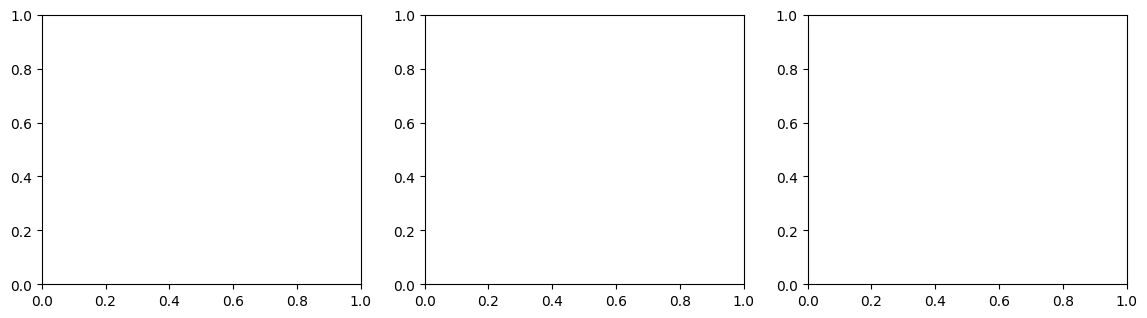

In [13]:
epochs = range(num_epochs)
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
for ax, key, title in [
    (axes[0], 'total', 'Total loss'),
    (axes[1], 'vrp',   'VRP loss'),
    (axes[2], 'mr',    'MR loss'),
]:
    ax.plot(epochs, history[f'train_{key}'], label='train')
    ax.plot(epochs, history[f'val_{key}'],   label='val', alpha=0.8)
    ax.set_title(title);  ax.set_xlabel('Epoch');  ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('gru_signals_loss.png', bbox_inches='tight', dpi=150)
plt.show()

## Inference — collect predictions

In [14]:
def collect_preds(loader, dataset):
    model.eval()
    p_vrp_list, p_mr_list = [], []
    y_vrp_list, y_mr_list, mask_list = [], [], []
    with torch.no_grad():
        for xb, yv, ym, mask, wt in loader:
            pv, pm = model(xb)
            p_vrp_list.append(pv.numpy());  p_mr_list.append(pm.numpy())
            y_vrp_list.append(yv.numpy());  y_mr_list.append(ym.numpy())
            mask_list.append(mask.numpy())
    p_vrp  = np.concatenate(p_vrp_list)
    p_mr   = np.concatenate(p_mr_list)
    y_vrp  = np.concatenate(y_vrp_list)
    y_mr   = np.concatenate(y_mr_list)
    mask   = np.concatenate(mask_list)
    anchors = np.array(dataset.anchor_indices)
    return p_vrp, p_mr, y_vrp, y_mr, mask, anchors

pv_tr, pm_tr, yv_tr, ym_tr, mask_tr_pred, anch_tr = collect_preds(train_loader, train_ds)
pv_te, pm_te, yv_te, ym_te, mask_te_pred, anch_te = collect_preds(test_loader,  test_ds)

print(f'Train predictions: {len(pv_tr)}   Test predictions: {len(pv_te)}')

Train predictions: 557   Test predictions: 257


## Calibration plots

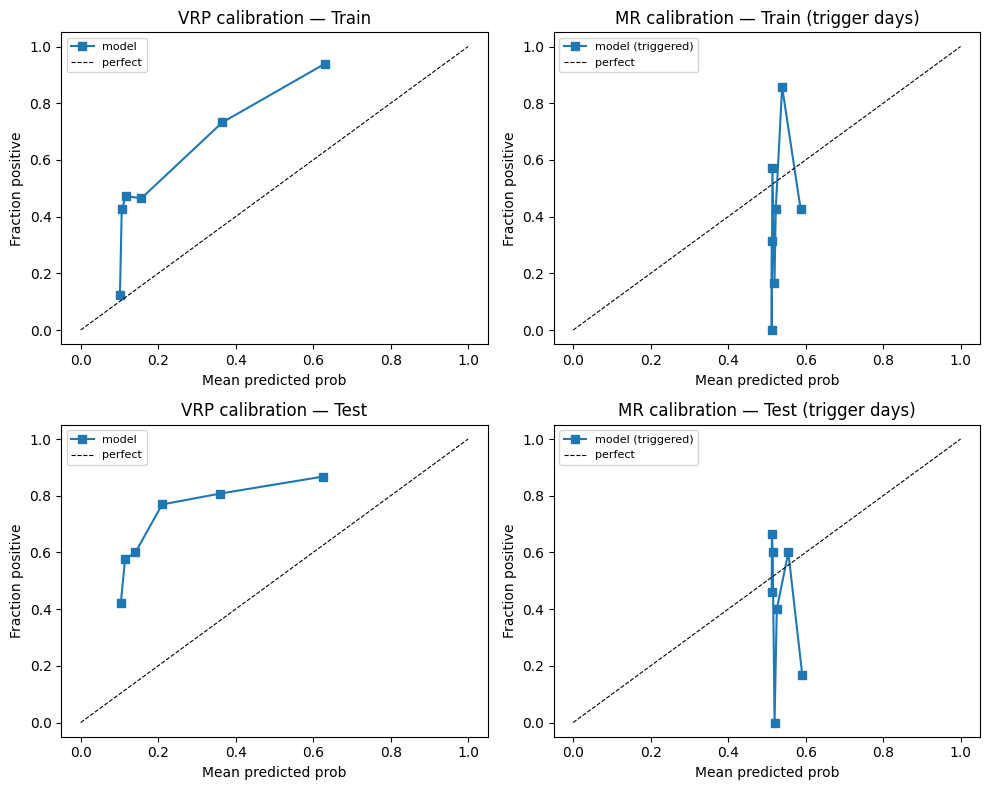

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for row, (split, pv, pm, yv, ym, msk) in enumerate([
    ('Train', pv_tr, pm_tr, yv_tr, ym_tr, mask_tr_pred),
    ('Test',  pv_te, pm_te, yv_te, ym_te, mask_te_pred),
]):
    # VRP calibration
    ax = axes[row, 0]
    frac_pos, mean_pred = calibration_curve(yv.astype(int), pv, n_bins=10, strategy='quantile')
    ax.plot(mean_pred, frac_pos, 's-', label='model')
    ax.plot([0, 1], [0, 1], 'k--', lw=0.8, label='perfect')
    ax.set_title(f'VRP calibration — {split}');  ax.set_xlabel('Mean predicted prob')
    ax.set_ylabel('Fraction positive');  ax.legend(fontsize=8)

    # MR calibration (triggered days only)
    ax = axes[row, 1]
    trig_idx = msk.astype(bool)
    if trig_idx.sum() > 10:
        frac_pos, mean_pred = calibration_curve(
            ym[trig_idx].astype(int), pm[trig_idx], n_bins=8, strategy='quantile'
        )
        ax.plot(mean_pred, frac_pos, 's-', label='model (triggered)')
        ax.plot([0, 1], [0, 1], 'k--', lw=0.8, label='perfect')
    ax.set_title(f'MR calibration — {split} (trigger days)');
    ax.set_xlabel('Mean predicted prob');  ax.set_ylabel('Fraction positive')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('gru_signals_calibration.png', bbox_inches='tight', dpi=150)
plt.show()

## Confusion matrices

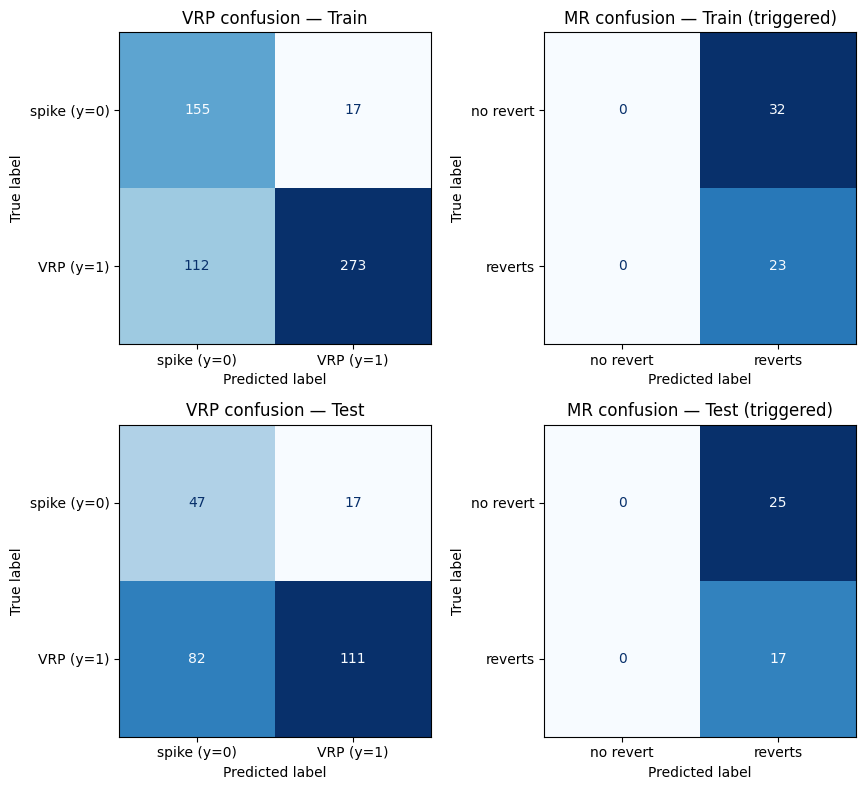

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(9, 8))

for row, (split, pv, pm, yv, ym, msk) in enumerate([
    ('Train', pv_tr, pm_tr, yv_tr, ym_tr, mask_tr_pred),
    ('Test',  pv_te, pm_te, yv_te, ym_te, mask_te_pred),
]):
    # VRP
    cm_v = confusion_matrix(yv.astype(int), (pv > 0.5).astype(int))
    ConfusionMatrixDisplay(cm_v, display_labels=['spike (y=0)', 'VRP (y=1)']).plot(
        ax=axes[row, 0], colorbar=False, cmap='Blues'
    )
    axes[row, 0].set_title(f'VRP confusion — {split}')

    # MR (triggered days only)
    trig_idx = msk.astype(bool)
    if trig_idx.sum() > 0:
        cm_m = confusion_matrix(ym[trig_idx].astype(int), (pm[trig_idx] > 0.5).astype(int))
        ConfusionMatrixDisplay(cm_m, display_labels=['no revert', 'reverts']).plot(
            ax=axes[row, 1], colorbar=False, cmap='Blues'
        )
    axes[row, 1].set_title(f'MR confusion — {split} (triggered)')

plt.tight_layout()
plt.savefig('gru_signals_confusion.png', bbox_inches='tight', dpi=150)
plt.show()

## Time-series of predicted probabilities (test set)

DateParseError: Unknown datetime string format, unable to parse: 2021-06- 01

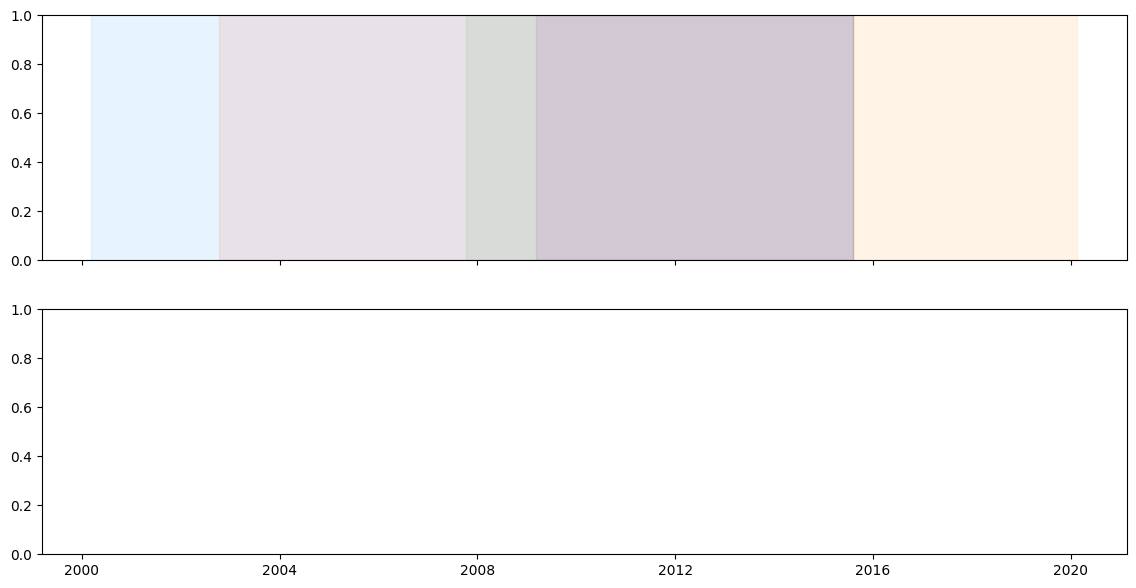

In [17]:
test_anchor_dates = fast_test_dates[anch_te]

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

for ax, probs, label, color in [
    (axes[0], pv_te, 'p_vrp  (Pr[VRP realised])', 'steelblue'),
    (axes[1], pm_te, 'p_mr   (Pr[reverts | triggered])', 'darkorange'),
]:
    for lbl, col, start, end in regime_colors:
        ax.axvspan(
            max(pd.Timestamp(start), test_anchor_dates[0]),
            min(pd.Timestamp(end),   test_anchor_dates[-1]),
            alpha=0.10, color=col
        )
    ax.plot(test_anchor_dates, probs, lw=0.7, color=color, alpha=0.85)
    ax.axhline(0.5, color='k', lw=0.6, ls='--')
    ax.set_ylim(0, 1);  ax.set_ylabel(label, fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

axes[0].set_title('VRP signal — test set (p > 0.5: sell vol; p < 0.5: spike risk)')
axes[1].set_title('MR signal  — test set (meaningful only on trigger days |z| > 2)')

fig.legend(handles=legend_patches, loc='lower center', ncol=4, fontsize=8,
           bbox_to_anchor=(0.5, -0.04))
plt.tight_layout()
plt.savefig('gru_signals_timeseries.png', bbox_inches='tight', dpi=150)
plt.show()

## VRP head: overlay on VIX vs realised-RV spread (test set)

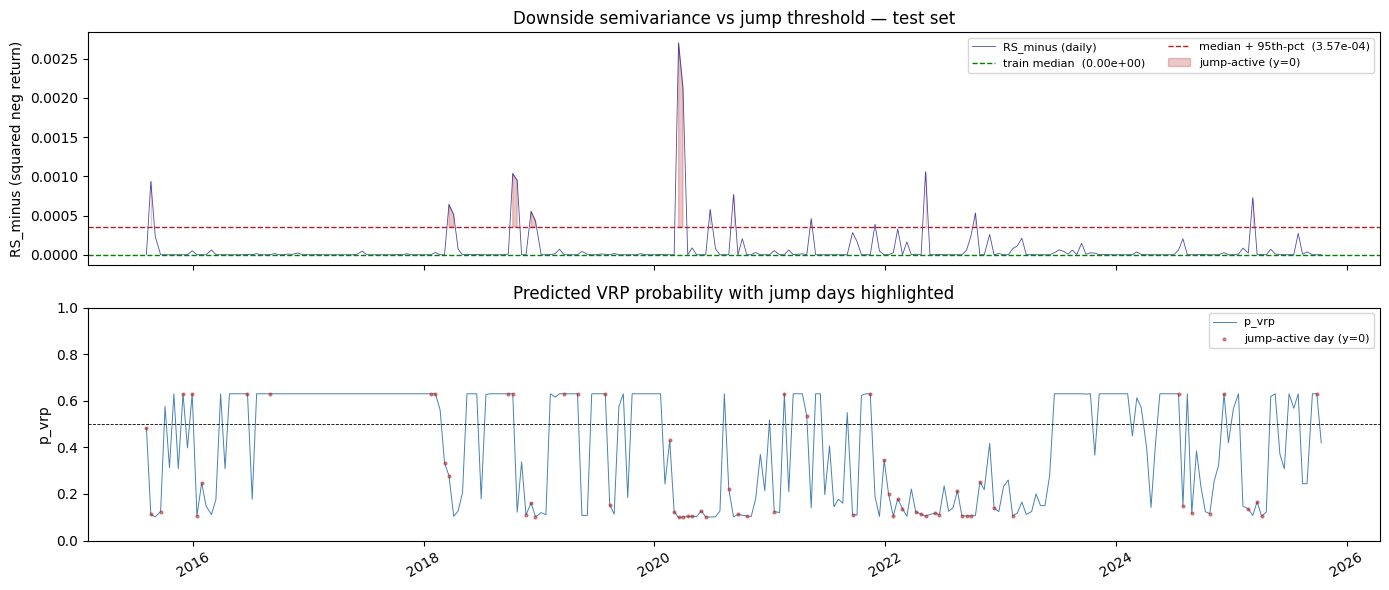

In [18]:
# RS_minus on test anchor days vs the two threshold lines
rm_te_anch   = rs_minus_te[anch_te]
thresh_line  = rs_minus_median_tr + jump_threshold_tr   # = median + 95th-pct jump threshold

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

ax = axes[0]
ax.plot(test_anchor_dates, rm_te_anch, lw=0.6, color='navy', alpha=0.7, label='RS_minus (daily)')
ax.axhline(rs_minus_median_tr, color='green',    lw=1.0, ls='--', label=f'train median  ({rs_minus_median_tr:.2e})')
ax.axhline(thresh_line,        color='firebrick', lw=1.0, ls='--', label=f'median + 95th-pct  ({thresh_line:.2e})')
ax.fill_between(test_anchor_dates, thresh_line, rm_te_anch,
                where=rm_te_anch > thresh_line,
                alpha=0.25, color='firebrick', label='jump-active (y=0)')
ax.set_ylabel('RS_minus (squared neg return)');  ax.legend(fontsize=8, ncol=2)
ax.set_title('Downside semivariance vs jump threshold — test set')

ax = axes[1]
ax.plot(test_anchor_dates, pv_te, lw=0.7, color='steelblue', label='p_vrp')
ax.scatter(test_anchor_dates[yv_te == 0], pv_te[yv_te == 0],
           s=4, color='firebrick', alpha=0.5, zorder=3, label='jump-active day (y=0)')
ax.axhline(0.5, color='k', lw=0.6, ls='--')
ax.set_ylim(0, 1);  ax.set_ylabel('p_vrp');  ax.legend(fontsize=8)
ax.set_title('Predicted VRP probability with jump days highlighted')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

plt.tight_layout()
plt.savefig('gru_signals_vrp_overlay.png', bbox_inches='tight', dpi=150)
plt.show()

## MR head: overlay on price z-score (test set, triggered days only)

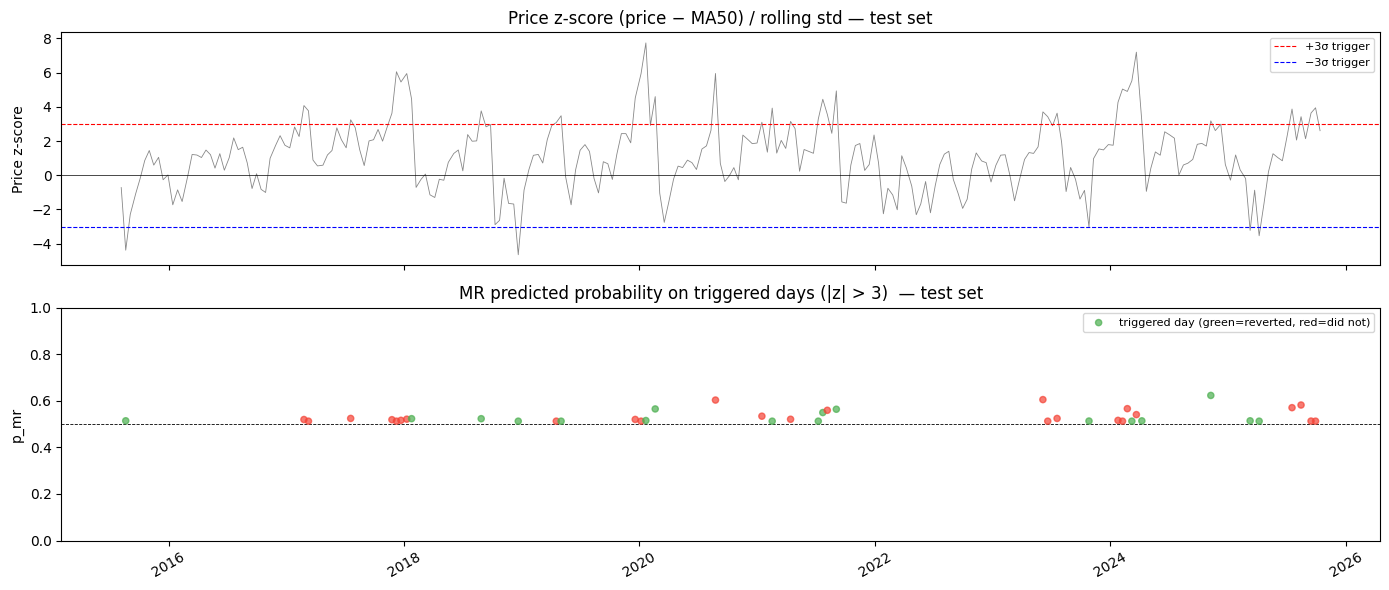

In [19]:
pz_te_anch   = pzscore_te[anch_te]
trig_te_pred = mask_te_pred.astype(bool)

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

ax = axes[0]
ax.plot(test_anchor_dates, pz_te_anch, lw=0.6, color='#555555', alpha=0.7)
ax.axhline( 3.0, color='red',   lw=0.8, ls='--', label='+3σ trigger')
ax.axhline(-3.0, color='blue',  lw=0.8, ls='--', label='−3σ trigger')
ax.axhline( 0.0, color='k',     lw=0.5)
ax.set_ylabel('Price z-score');  ax.legend(fontsize=8)
ax.set_title('Price z-score (price − MA50) / rolling std — test set')

ax = axes[1]
if trig_te_pred.sum() > 0:
    trig_dates = test_anchor_dates[trig_te_pred]
    trig_pm    = pm_te[trig_te_pred]
    trig_ym    = ym_te[trig_te_pred]
    ax.scatter(trig_dates, trig_pm,
               c=np.where(trig_ym == 1, '#4CAF50', '#F44336'),
               s=20, alpha=0.7, zorder=3,
               label='triggered day (green=reverted, red=did not)')
    ax.axhline(0.5, color='k', lw=0.6, ls='--')
ax.set_ylim(0, 1);  ax.set_ylabel('p_mr');  ax.legend(fontsize=8)
ax.set_title('MR predicted probability on triggered days (|z| > 3)  — test set')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

plt.tight_layout()
plt.savefig('gru_signals_mr_overlay.png', bbox_inches='tight', dpi=150)
plt.show()